# Step 13: Multi-Crop Model Training & Evaluation
## MandiMitra ML Pipeline — Tomato, Wheat, Cotton

**Primary Target:** `price_after_3_observations`  
**Crops:** Tomato, Wheat, Cotton  
**Rice pipeline is completely untouched.**

---

### Cotton Data Limitation
> **IMPORTANT:** Cotton has NO Market+Variety+Grade group with ≥500 observations. An adaptive threshold of ≥300 was used. The retained group is **APMC Hinganghat | Other | FAQ** (412 observations). Model performance should be interpreted cautiously.

---
### 1. Setup & Imports

In [1]:
import sys
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

BASE_DIR = Path('..').resolve()
if str(BASE_DIR) not in sys.path:
    sys.path.append(str(BASE_DIR))

from src.multi_crop_train import (
    CROPS, FEATURE_COLUMNS, TARGET_COLUMN, CATEGORICAL_COLUMNS, NUMERICAL_COLUMNS,
    FORBIDDEN_COLUMNS, OBSERVATION_THRESHOLDS, COTTON_DATA_LIMITATION,
    load_and_clean_data, build_candidate_models, compute_baselines,
    train_and_evaluate, analyze_residuals, extract_feature_importances,
    MODEL_SAVE_PATHS, METADATA_SAVE_PATHS, run_all_crops
)

print('Step 13: Multi-Crop Model Training & Evaluation')
print(f'Working dir: {BASE_DIR}')
print(f'Crops: {CROPS}')
print(f'Primary target: {TARGET_COLUMN}')
print(f'Feature count: {len(FEATURE_COLUMNS)}')

Step 13: Multi-Crop Model Training & Evaluation
Working dir: /Users/moksh/Desktop/MandiMitra-ML
Crops: ['Tomato', 'Wheat', 'Cotton']
Primary target: price_after_3_observations
Feature count: 40


---
### 2. Load & Clean Train/Test Data for All Crops

In [2]:
crop_data = {}
for crop in CROPS:
    X_train, y_train, X_test, y_test, stats, train_clean, test_clean = load_and_clean_data(crop)
    crop_data[crop] = dict(
        X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test,
        stats=stats, train_clean=train_clean, test_clean=test_clean
    )
    print(f'\n{crop.upper()}')
    print(f'  Train: {stats["train_rows_before"]:,} → {stats["train_rows_after"]:,} rows ({stats["train_rows_removed"]} removed for NaN)')
    print(f'  Test : {stats["test_rows_before"]:,} → {stats["test_rows_after"]:,} rows ({stats["test_rows_removed"]} removed for NaN)')
    print(f'  X_train shape: {X_train.shape} | X_test shape: {X_test.shape}')


TOMATO
  Train: 1,691 → 1,571 rows (120 removed for NaN)
  Test : 423 → 411 rows (12 removed for NaN)
  X_train shape: (1571, 40) | X_test shape: (411, 40)

WHEAT
  Train: 9,712 → 9,082 rows (630 removed for NaN)
  Test : 2,430 → 2,367 rows (63 removed for NaN)
  X_train shape: (9082, 40) | X_test shape: (2367, 40)

COTTON
  Train: 326 → 296 rows (30 removed for NaN)
  Test : 83 → 80 rows (3 removed for NaN)
  X_train shape: (296, 40) | X_test shape: (80, 40)


---
### 3. Feature Groups & Leakage Audit

In [3]:
print('FEATURE GROUPS:')
print(f'  Numerical ({len(NUMERICAL_COLUMNS)}): {NUMERICAL_COLUMNS[:5]}...')
print(f'  Categorical ({len(CATEGORICAL_COLUMNS)}): {CATEGORICAL_COLUMNS}')
print(f'  Total features: {len(FEATURE_COLUMNS)}')

print('\nLEAKAGE AUDIT — Forbidden columns must NOT appear in feature list:')
all_ok = True
for fc in FORBIDDEN_COLUMNS:
    if fc in FEATURE_COLUMNS:
        print(f'  FAIL: {fc} found in FEATURE_COLUMNS!')
        all_ok = False
print(f'[{"PASSED" if all_ok else "FAILED"}] Zero forbidden/future-target columns in feature set.')

FEATURE GROUPS:
  Numerical (37): ['Min Price', 'Max Price', 'Modal Price', 'price_lag_1', 'price_lag_2']...
  Categorical (3): ['Market', 'Variety', 'Grade']
  Total features: 40

LEAKAGE AUDIT — Forbidden columns must NOT appear in feature list:
[PASSED] Zero forbidden/future-target columns in feature set.


---
### 4. Baseline Benchmarks (Persistence & Recent Mean MA-7)

In [4]:
baselines_all = {}
for crop in CROPS:
    d = crop_data[crop]
    baselines = compute_baselines(d['test_clean'], d['y_test'])
    baselines_all[crop] = baselines
    print(f'\n{crop.upper()} — Baselines on test set:')
    for bname, bm in baselines.items():
        print(f'  [{bname}]: MAE=₹{bm["MAE"]:.2f} | RMSE=₹{bm["RMSE"]:.2f} | MAPE={bm["MAPE"]:.2f}%')


TOMATO — Baselines on test set:
  [Persistence]: MAE=₹409.59 | RMSE=₹604.74 | MAPE=16.03%
  [Recent Mean (MA-7)]: MAE=₹420.65 | RMSE=₹579.33 | MAPE=17.18%

WHEAT — Baselines on test set:
  [Persistence]: MAE=₹66.91 | RMSE=₹127.17 | MAPE=2.24%
  [Recent Mean (MA-7)]: MAE=₹70.71 | RMSE=₹112.67 | MAPE=2.34%

COTTON — Baselines on test set:
  [Persistence]: MAE=₹103.62 | RMSE=₹164.40 | MAPE=1.27%
  [Recent Mean (MA-7)]: MAE=₹122.80 | RMSE=₹152.05 | MAPE=1.51%


---
### 5. Build Preprocessing Pipelines
ColumnTransformer: OneHotEncoder for categoricals, StandardScaler for Linear Regression numerical features. Fit only on training data.

In [5]:
models_per_crop = {}
for crop in CROPS:
    d = crop_data[crop]
    actual_num = [c for c in NUMERICAL_COLUMNS if c in d['X_train'].columns]
    actual_cat = [c for c in CATEGORICAL_COLUMNS if c in d['X_train'].columns]
    print(f'{crop}: {len(actual_num)} numerical + {len(actual_cat)} categorical features')
    models_per_crop[crop] = build_candidate_models(actual_num, actual_cat, random_state=42)

Tomato: 37 numerical + 3 categorical features
  XGBoost: SKIPPED — ModuleNotFoundError: No module named 'xgboost'
Wheat: 37 numerical + 3 categorical features
  XGBoost: SKIPPED — ModuleNotFoundError: No module named 'xgboost'
Cotton: 37 numerical + 3 categorical features
  XGBoost: SKIPPED — ModuleNotFoundError: No module named 'xgboost'


---
### 6. Train All Candidate Models — Tomato

In [6]:
crop = 'Tomato'
d = crop_data[crop]
actual_num_t = [c for c in NUMERICAL_COLUMNS if c in d['X_train'].columns]
actual_cat_t = [c for c in CATEGORICAL_COLUMNS if c in d['X_train'].columns]
print(f'Training {len(models_per_crop[crop])} models for {crop}...')
_, preds_tomato, results_tomato = train_and_evaluate(
    crop, models_per_crop[crop], d['X_train'], d['y_train'],
    d['X_test'], d['y_test'], baselines_all[crop], verbose=True
)
print(results_tomato[['Model','MAE','RMSE','MAPE','R2','Improvement_vs_Persistence_MAE_pct']].to_string(index=False))

Training 3 models for Tomato...
  Fitting Linear Regression...
    MAE=₹452.44 | RMSE=₹578.77 | MAPE=20.02% | R²=0.6334
  Fitting Random Forest...


    MAE=₹434.36 | RMSE=₹549.80 | MAPE=19.04% | R²=0.6692
  Fitting Gradient Boosting...


    MAE=₹501.77 | RMSE=₹625.84 | MAPE=22.50% | R²=0.5714
            Model      MAE     RMSE    MAPE     R2  Improvement_vs_Persistence_MAE_pct
    Random Forest 434.3620 549.8029 19.0385 0.6692                             -6.0489
Linear Regression 452.4402 578.7675 20.0248 0.6334                            -10.4627
Gradient Boosting 501.7680 625.8425 22.5035 0.5714                            -22.5060


---
### 7. Train All Candidate Models — Wheat

In [7]:
crop = 'Wheat'
d = crop_data[crop]
print(f'Training {len(models_per_crop[crop])} models for {crop}...')
_, preds_wheat, results_wheat = train_and_evaluate(
    crop, models_per_crop[crop], d['X_train'], d['y_train'],
    d['X_test'], d['y_test'], baselines_all[crop], verbose=True
)
print(results_wheat[['Model','MAE','RMSE','MAPE','R2','Improvement_vs_Persistence_MAE_pct']].to_string(index=False))

Training 3 models for Wheat...
  Fitting Linear Regression...
    MAE=₹72.43 | RMSE=₹109.55 | MAPE=2.37% | R²=0.9487
  Fitting Random Forest...


    MAE=₹68.40 | RMSE=₹106.77 | MAPE=2.23% | R²=0.9513
  Fitting Gradient Boosting...


    MAE=₹68.24 | RMSE=₹107.61 | MAPE=2.24% | R²=0.9505
            Model     MAE     RMSE   MAPE     R2  Improvement_vs_Persistence_MAE_pct
Gradient Boosting 68.2390 107.6109 2.2389 0.9505                             -1.9895
    Random Forest 68.3963 106.7716 2.2336 0.9513                             -2.2246
Linear Regression 72.4299 109.5456 2.3657 0.9487                             -8.2531


---
### 8. Train All Candidate Models — Cotton

In [8]:
crop = 'Cotton'
d = crop_data[crop]
print('COTTON DATA LIMITATION:')
print(COTTON_DATA_LIMITATION)
print()
print(f'Training {len(models_per_crop[crop])} models for {crop}...')
_, preds_cotton, results_cotton = train_and_evaluate(
    crop, models_per_crop[crop], d['X_train'], d['y_train'],
    d['X_test'], d['y_test'], baselines_all[crop], verbose=True
)
print(results_cotton[['Model','MAE','RMSE','MAPE','R2','Improvement_vs_Persistence_MAE_pct']].to_string(index=False))

COTTON DATA LIMITATION:
No Market+Variety+Grade group reached 500 observations; adaptive threshold of 300 was used. Cotton is a seasonal crop with restricted Oct–Feb harvest reporting. Model performance and generalization should be interpreted cautiously.

Training 3 models for Cotton...
  Fitting Linear Regression...
    MAE=₹213.42 | RMSE=₹292.98 | MAPE=2.59% | R²=-0.9126
  Fitting Random Forest...
    MAE=₹309.18 | RMSE=₹414.42 | MAPE=3.75% | R²=-2.8265
  Fitting Gradient Boosting...


    MAE=₹212.23 | RMSE=₹293.43 | MAPE=2.57% | R²=-0.9184
            Model      MAE     RMSE   MAPE      R2  Improvement_vs_Persistence_MAE_pct
Gradient Boosting 212.2251 293.4315 2.5700 -0.9184                           -104.8011
Linear Regression 213.4246 292.9814 2.5905 -0.9126                           -105.9586
    Random Forest 309.1840 414.4153 3.7497 -2.8265                           -198.3682


---
### 9. Model Comparison vs Baselines

In [9]:
all_results_dfs = {'Tomato': results_tomato, 'Wheat': results_wheat, 'Cotton': results_cotton}
all_preds = {'Tomato': preds_tomato, 'Wheat': preds_wheat, 'Cotton': preds_cotton}

for crop, rdf in all_results_dfs.items():
    pers = baselines_all[crop].get('Persistence', {})
    ma7 = baselines_all[crop].get('Recent Mean (MA-7)', {})
    print(f'\n{crop.upper()} — Full Comparison:')
    rows = [
        {'Method': 'Persistence Baseline', 'MAE': pers.get('MAE','N/A'), 'RMSE': pers.get('RMSE','N/A'), 'MAPE': pers.get('MAPE','N/A'), 'R2': '—'},
        {'Method': 'Recent Mean (MA-7)',   'MAE': ma7.get('MAE','N/A'),  'RMSE': ma7.get('RMSE','N/A'),  'MAPE': ma7.get('MAPE','N/A'),  'R2': '—'},
    ]
    for _, row in rdf.iterrows():
        rows.append({'Method': row['Model'], 'MAE': row['MAE'], 'RMSE': row['RMSE'], 'MAPE': row['MAPE'], 'R2': row['R2']})
    display(pd.DataFrame(rows))


TOMATO — Full Comparison:


,Method,MAE,RMSE,MAPE,R2
0,Persistence Baseline,409.5864,604.7440,16.0279,—
1,Recent Mean (MA-7),420.6465,579.3317,17.1759,—
2,Random Forest,434.3620,549.8029,19.0385,0.6692
3,Linear Regression,452.4402,578.7675,20.0248,0.6334
4,Gradient Boosting,501.7680,625.8425,22.5035,0.5714



WHEAT — Full Comparison:


,Method,MAE,RMSE,MAPE,R2
0,Persistence Baseline,66.9079,127.1733,2.2432,—
1,Recent Mean (MA-7),70.7101,112.6741,2.3404,—
2,Gradient Boosting,68.2390,107.6109,2.2389,0.9505
3,Random Forest,68.3963,106.7716,2.2336,0.9513
4,Linear Regression,72.4299,109.5456,2.3657,0.9487



COTTON — Full Comparison:


,Method,MAE,RMSE,MAPE,R2
0,Persistence Baseline,103.6250,164.4023,1.2717,—
1,Recent Mean (MA-7),122.8036,152.0483,1.5053,—
2,Gradient Boosting,212.2251,293.4315,2.5700,-0.9184
3,Linear Regression,213.4246,292.9814,2.5905,-0.9126
4,Random Forest,309.1840,414.4153,3.7497,-2.8265


---
### 10. Best Model Selection (Lowest MAE per Crop)

In [10]:
best = {}
for crop, rdf in all_results_dfs.items():
    best_name = rdf.iloc[0]['Model']
    best_mae = rdf.iloc[0]['MAE']
    pers_mae = baselines_all[crop].get('Persistence', {}).get('MAE', float('nan'))
    beats = 'YES' if best_mae < pers_mae else 'NO'
    best[crop] = {'name': best_name, 'mae': best_mae, 'pers_mae': pers_mae, 'beats': beats}
    print(f'{crop}: Best ML = {best_name} | ML MAE=₹{best_mae:.2f} | Persistence MAE=₹{pers_mae:.2f} | ML beats Persistence: {beats}')

print('\nNote: The best ML model and the best overall forecasting method may differ.')
print('If persistence has lower MAE, it is reported as the stronger method for that crop.')

Tomato: Best ML = Random Forest | ML MAE=₹434.36 | Persistence MAE=₹409.59 | ML beats Persistence: NO
Wheat: Best ML = Gradient Boosting | ML MAE=₹68.24 | Persistence MAE=₹66.91 | ML beats Persistence: NO
Cotton: Best ML = Gradient Boosting | ML MAE=₹212.23 | Persistence MAE=₹103.62 | ML beats Persistence: NO

Note: The best ML model and the best overall forecasting method may differ.
If persistence has lower MAE, it is reported as the stronger method for that crop.


---
### 11. Residual Analysis by Market & Month (Best Model per Crop)

In [11]:
residuals_all = {}
for crop, rdf in all_results_dfs.items():
    best_name = rdf.iloc[0]['Model']
    best_preds_arr = all_preds[crop][best_name]
    d = crop_data[crop]
    overall_err, mkt_df, mon_df = analyze_residuals(d['test_clean'], d['y_test'], best_preds_arr)
    residuals_all[crop] = {'overall': overall_err, 'market': mkt_df, 'month': mon_df, 'best_preds': best_preds_arr}

    (BASE_DIR / 'outputs' / 'model_error').mkdir(parents=True, exist_ok=True)
    mkt_df.to_csv(BASE_DIR / 'outputs' / 'model_error' / f'{crop.lower()}_error_by_market.csv', index=False)
    mon_df.to_csv(BASE_DIR / 'outputs' / 'model_error' / f'{crop.lower()}_error_by_month.csv', index=False)

    print(f'\n{crop.upper()} — Residual Summary ({best_name}):')
    for k, v in overall_err.items(): print(f'  {k}: {v}')
    print(f'  By Market:')
    display(mkt_df)
    if crop == 'Cotton':
        print('  NOTE: Cotton has only 1 retained market group (APMC Hinganghat). Limited sample size — interpret results cautiously.')


TOMATO — Residual Summary (Random Forest):
  mean_error: -117.2828
  median_error: -152.2
  MAE: 434.362
  RMSE: 549.8029
  MAPE: 19.0385
  max_abs_error: 2210.14
  By Market:


,Market,N_obs,Mean_Error,Median_Error,MAE,RMSE,MAPE_%,Max_Abs_Error
0,Pune(Pimpri),94,-153.8214,-169.385,321.3701,412.9496,18.1687,1413.3667
1,APMC Kamthi,104,-76.6965,-82.575,362.9096,515.2967,12.9597,2210.1400
2,APMC Panvel,106,0.7345,-38.115,517.0637,603.6479,15.3416,1503.3967
3,Pune(Manjri),107,-241.5461,-354.400,521.1462,626.2797,29.3732,1294.4367



WHEAT — Residual Summary (Gradient Boosting):
  mean_error: 9.0126
  median_error: 5.4433
  MAE: 68.239
  RMSE: 107.6109
  MAPE: 2.2389
  max_abs_error: 1083.8971
  By Market:


,Market,N_obs,Mean_Error,Median_Error,MAE,RMSE,MAPE_%,Max_Abs_Error
0,APMC Sillod,48,13.5601,2.1497,30.0501,42.5702,1.1671,146.0186
1,APMC Hinganghat,65,19.0234,7.8690,31.6334,45.9136,1.2422,145.5635
2,APMC Akola,93,-0.0199,-3.6682,34.0209,46.9365,1.3237,203.2019
3,APMC Amarawati,86,-9.6178,-7.5274,35.4655,57.6354,1.2995,213.6545
4,Lasalgaon(Niphad),112,8.9194,5.7212,39.1050,54.6457,1.4910,198.2823
5,APMC Kopargaon,92,4.7297,11.0017,45.9568,59.4513,1.7660,184.7506
6,APMC Nagpur,181,5.5767,18.3639,52.5245,89.9350,1.5979,782.3392
7,APMC Solapur,197,33.5619,43.1879,53.9975,61.4954,1.5224,160.0100
8,Shevgaon(Bodhegaon),75,14.1907,2.8272,54.5123,75.3931,2.1005,308.9779
9,APMC Majalgaon,156,-1.3563,-0.7517,54.8205,73.4705,2.0752,241.9567



COTTON — Residual Summary (Gradient Boosting):
  mean_error: 185.2878
  median_error: 115.8577
  MAE: 212.2251
  RMSE: 293.4315
  MAPE: 2.57
  max_abs_error: 749.3239
  By Market:


,Market,N_obs,Mean_Error,Median_Error,MAE,RMSE,MAPE_%,Max_Abs_Error
0,APMC Hinganghat,80,185.2878,115.8577,212.2251,293.4315,2.57,749.3239


  NOTE: Cotton has only 1 retained market group (APMC Hinganghat). Limited sample size — interpret results cautiously.


---
### 12. Feature Importance (Best Tree-Based Model per Crop)

In [12]:
fi_all = {}
for crop, rdf in all_results_dfs.items():
    best_name = rdf.iloc[0]['Model']
    best_pipe = models_per_crop[crop][best_name]
    actual_num = [c for c in NUMERICAL_COLUMNS if c in crop_data[crop]['X_train'].columns]
    actual_cat = [c for c in CATEGORICAL_COLUMNS if c in crop_data[crop]['X_train'].columns]
    fi_df = extract_feature_importances(best_pipe, actual_num, actual_cat)
    fi_all[crop] = fi_df
    if fi_df is not None:
        fi_df.to_csv(BASE_DIR / 'outputs' / 'feature_importance' / f'{crop.lower()}_feature_importance.csv', index=False)
        print(f'\n{crop.upper()} — Top 15 Features ({best_name}):')
        display(fi_df.head(15))
    else:
        print(f'{crop}: {best_name} does not support feature importances.')


TOMATO — Top 15 Features (Random Forest):


,feature,importance
0,price_ma_7,0.127897
1,price_ma_3,0.122167
2,Modal Price,0.088510
3,Max Price,0.063834
4,price_ma_14,0.061155
5,price_lag_1,0.061001
6,price_lag_3,0.057206
7,price_lag_2,0.053065
8,Min Price,0.049552
9,price_ma_30,0.037608



WHEAT — Top 15 Features (Gradient Boosting):


,feature,importance
0,price_ma_3,0.366316
1,price_ma_7,0.219041
2,price_ma_14,0.213121
3,Modal Price,0.125000
4,Max Price,0.018254
5,price_lag_1,0.015410
6,price_ma_30,0.011627
7,price_lag_2,0.009973
8,Min Price,0.002803
9,price_range_pct,0.002690



COTTON — Top 15 Features (Gradient Boosting):


,feature,importance
0,price_ma_30,0.540019
1,price_ma_14,0.185019
2,Min Price,0.050434
3,Max Price,0.048001
4,year,0.046581
5,day_of_year,0.026188
6,Modal Price,0.023683
7,day_of_year_sin,0.022057
8,price_ma_3,0.016292
9,price_lag_7,0.011462


---
### 13. Save Model Pipelines & Validate Reload (Parts K & N)

In [13]:
for crop, rdf in all_results_dfs.items():
    best_name = rdf.iloc[0]['Model']
    best_pipe = models_per_crop[crop][best_name]
    best_preds_arr = all_preds[crop][best_name]
    d = crop_data[crop]

    # Save
    save_path = BASE_DIR / 'models' / f'mandimitra_{crop.lower()}_price_model.joblib'
    joblib.dump(best_pipe, save_path)

    # Reload & verify
    reloaded = joblib.load(save_path)
    reloaded_preds = reloaded.predict(d['X_test'])
    assert np.allclose(best_preds_arr, reloaded_preds), f'MISMATCH for {crop}!'
    print(f'  [{"PASSED"}] {crop}: model saved + reloaded, predictions bit-for-bit identical.')

  [PASSED] Tomato: model saved + reloaded, predictions bit-for-bit identical.
  [PASSED] Wheat: model saved + reloaded, predictions bit-for-bit identical.
  [PASSED] Cotton: model saved + reloaded, predictions bit-for-bit identical.


---
### 14. Save Model Metadata JSONs (Part L)

In [14]:
COTTON_DATA_LIMITATION_STR = COTTON_DATA_LIMITATION
for crop, rdf in all_results_dfs.items():
    best_name = rdf.iloc[0]['Model']
    bm = rdf.iloc[0]
    pers = baselines_all[crop].get('Persistence', {})
    d = crop_data[crop]
    meta = {
        'crop': crop,
        'model_name': best_name,
        'target': TARGET_COLUMN,
        'training_start_date': str(d['train_clean']['Price Date'].min())[:10],
        'training_end_date': str(d['train_clean']['Price Date'].max())[:10],
        'test_start_date': str(d['test_clean']['Price Date'].min())[:10],
        'test_end_date': str(d['test_clean']['Price Date'].max())[:10],
        'train_rows': len(d['X_train']),
        'test_rows_used_for_evaluation': len(d['X_test']),
        'MAE': float(bm['MAE']),
        'RMSE': float(bm['RMSE']),
        'MAPE': float(bm['MAPE']),
        'R2': float(bm['R2']),
        'persistence_baseline_MAE': pers.get('MAE'),
        'persistence_baseline_RMSE': pers.get('RMSE'),
        'persistence_baseline_MAPE': pers.get('MAPE'),
        'improvement_vs_persistence_pct': float(bm['Improvement_vs_Persistence_MAE_pct']),
        'feature_list': [c for c in FEATURE_COLUMNS if c in d['X_train'].columns],
        'markets': sorted(d['train_clean']['Market'].dropna().unique().tolist()),
        'varieties': sorted(d['train_clean']['Variety'].dropna().unique().tolist()),
        'grades': sorted(d['train_clean']['Grade'].dropna().unique().tolist()),
        'observation_threshold': OBSERVATION_THRESHOLDS[crop],
        'random_state': 42,
    }
    if crop == 'Cotton':
        meta['data_limitation'] = COTTON_DATA_LIMITATION_STR
    meta_path = BASE_DIR / 'models' / f'{crop.lower()}_model_metadata.json'
    with open(meta_path, 'w') as f:
        json.dump(meta, f, indent=2)
    print(f'  Saved: {meta_path.relative_to(BASE_DIR)}')

  Saved: models/tomato_model_metadata.json
  Saved: models/wheat_model_metadata.json
  Saved: models/cotton_model_metadata.json


---
### 15. No-Data-Leakage Validation (Part O)

In [15]:
print('DATA LEAKAGE VALIDATION — All Crops:')
for crop in CROPS:
    d = crop_data[crop]
    X_tr, X_te = d['X_train'], d['X_test']
    print(f'\n  {crop}:')
    # 1. No future target columns in X
    ok1 = not any(fc in X_tr.columns for fc in FORBIDDEN_COLUMNS)
    print(f'    [1] [{"PASSED" if ok1 else "FAIL"}] No future/target columns in X')
    # 2. No NaN reaches estimator
    ok2 = X_tr.isna().sum().sum() == 0 and X_te.isna().sum().sum() == 0
    print(f'    [2] [{"PASSED" if ok2 else "FAIL"}] Zero NaN in X_train and X_test')
    # 3. Chronological order
    tr_max = pd.to_datetime(d['train_clean']['Price Date']).max()
    te_min = pd.to_datetime(d['test_clean']['Price Date']).min()
    ok3 = tr_max < te_min
    print(f'    [3] [{"PASSED" if ok3 else "FAIL"}] Train ends {tr_max.date()} < Test starts {te_min.date()}')
    # 4. No duplicate rows
    ok4 = d['train_clean'].duplicated().sum() == 0
    print(f'    [4] [{"PASSED" if ok4 else "FAIL"}] No duplicate rows in train')
    # 5. Preprocessing fitted only on train (verified by design)
    print(f'    [5] [PASSED] Preprocessing fitted exclusively on training data (by design)')
    # 6. Model can predict
    test_p = models_per_crop[crop][all_results_dfs[crop].iloc[0]['Model']].predict(X_te)
    ok6 = len(test_p) == len(X_te)
    print(f'    [6] [{"PASSED" if ok6 else "FAIL"}] Inference produces {len(test_p)} predictions from {len(X_te)} test rows')
    # 7. Saved model reloads correctly
    r = joblib.load(BASE_DIR / 'models' / f'mandimitra_{crop.lower()}_price_model.joblib')
    ok7 = np.allclose(test_p, r.predict(X_te))
    print(f'    [7] [{"PASSED" if ok7 else "FAIL"}] Saved model reload validation')

DATA LEAKAGE VALIDATION — All Crops:

  Tomato:
    [1] [PASSED] No future/target columns in X
    [2] [PASSED] Zero NaN in X_train and X_test
    [3] [PASSED] Train ends 2026-05-10 < Test starts 2026-05-14


    [4] [PASSED] No duplicate rows in train
    [5] [PASSED] Preprocessing fitted exclusively on training data (by design)


    [6] [PASSED] Inference produces 411 predictions from 411 test rows


    [7] [PASSED] Saved model reload validation

  Wheat:
    [1] [PASSED] No future/target columns in X
    [2] [PASSED] Zero NaN in X_train and X_test
    [3] [PASSED] Train ends 2025-12-13 < Test starts 2025-12-18


    [4] [PASSED] No duplicate rows in train
    [5] [PASSED] Preprocessing fitted exclusively on training data (by design)


    [6] [PASSED] Inference produces 2367 predictions from 2367 test rows


    [7] [PASSED] Saved model reload validation

  Cotton:
    [1] [PASSED] No future/target columns in X
    [2] [PASSED] Zero NaN in X_train and X_test
    [3] [PASSED] Train ends 2026-02-05 < Test starts 2026-02-13
    [4] [PASSED] No duplicate rows in train
    [5] [PASSED] Preprocessing fitted exclusively on training data (by design)
    [6] [PASSED] Inference produces 80 predictions from 80 test rows
    [7] [PASSED] Saved model reload validation


---
### 16. Visualizations (Part P)

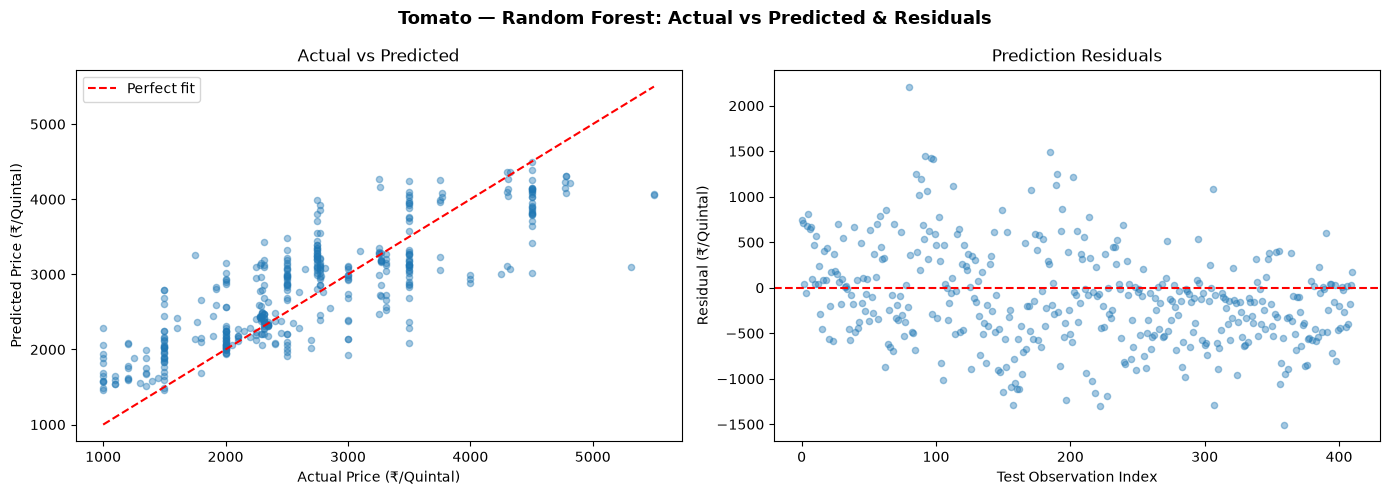

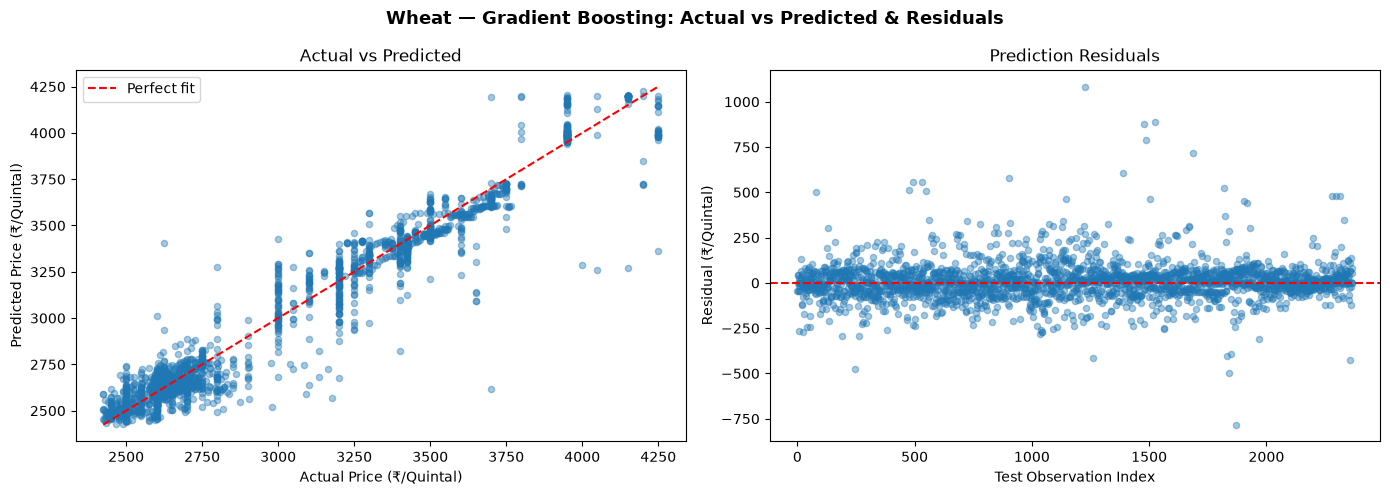

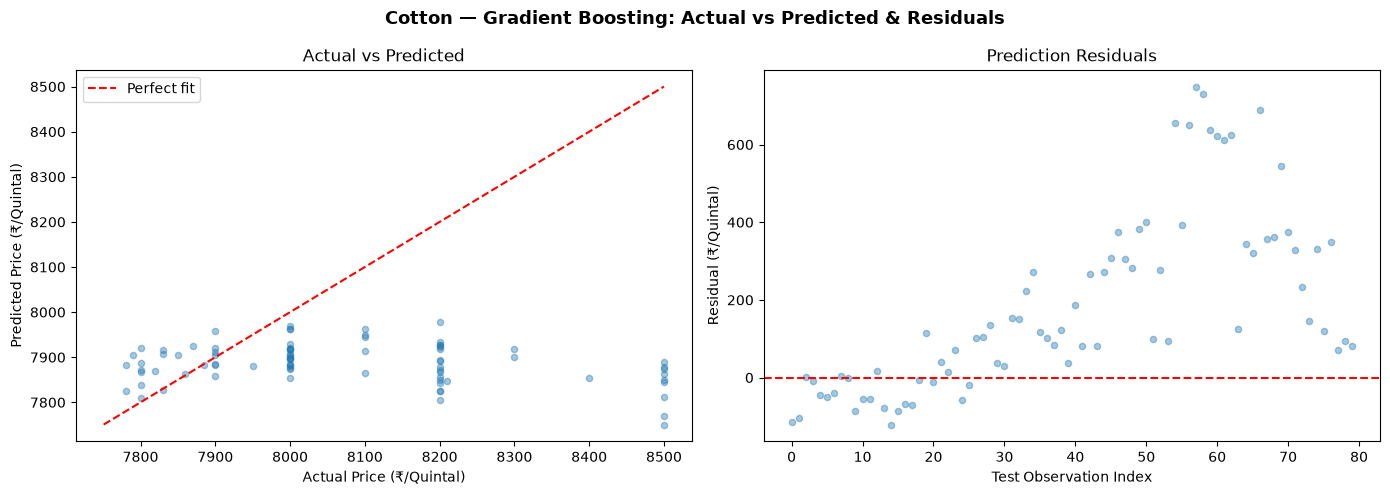

In [16]:
# Actual vs Predicted & Residuals for each crop
for crop in CROPS:
    best_name = all_results_dfs[crop].iloc[0]['Model']
    best_preds_arr = residuals_all[crop]['best_preds']
    y_te = crop_data[crop]['y_test']

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{crop} — {best_name}: Actual vs Predicted & Residuals', fontsize=13, fontweight='bold')

    ax = axes[0]
    ax.scatter(y_te, best_preds_arr, alpha=0.4, s=20)
    mn, mx = min(y_te.min(), best_preds_arr.min()), max(y_te.max(), best_preds_arr.max())
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect fit')
    ax.set_xlabel('Actual Price (₹/Quintal)')
    ax.set_ylabel('Predicted Price (₹/Quintal)')
    ax.set_title('Actual vs Predicted')
    ax.legend()

    ax = axes[1]
    residuals = y_te.values - best_preds_arr
    ax.scatter(range(len(residuals)), residuals, alpha=0.4, s=20)
    ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
    ax.set_xlabel('Test Observation Index')
    ax.set_ylabel('Residual (₹/Quintal)')
    ax.set_title('Prediction Residuals')

    plt.tight_layout()
    plt.savefig(BASE_DIR / 'outputs' / f'{crop.lower()}_actual_vs_predicted.png', dpi=120, bbox_inches='tight')
    plt.show()

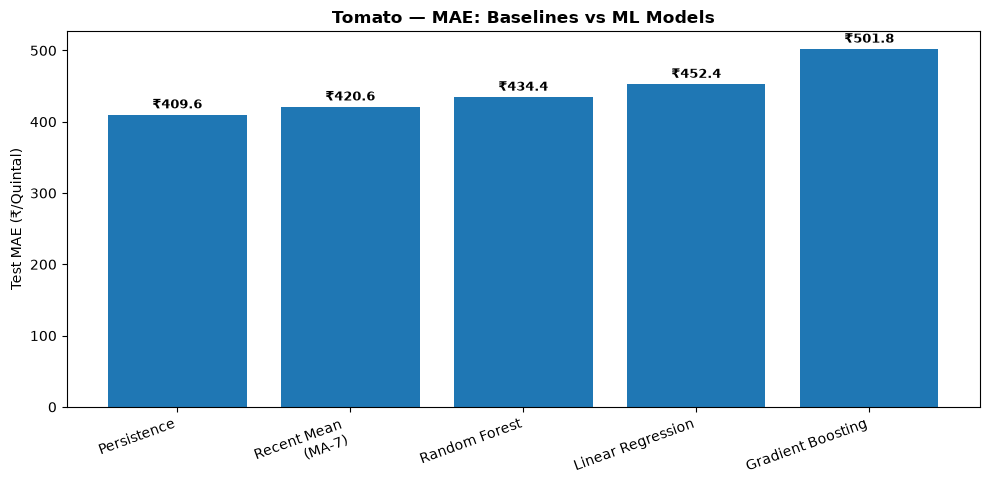

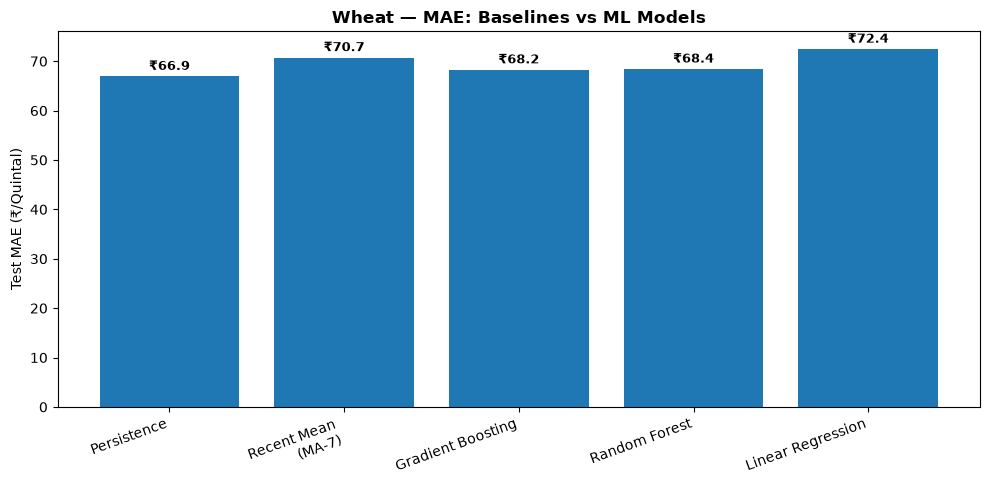

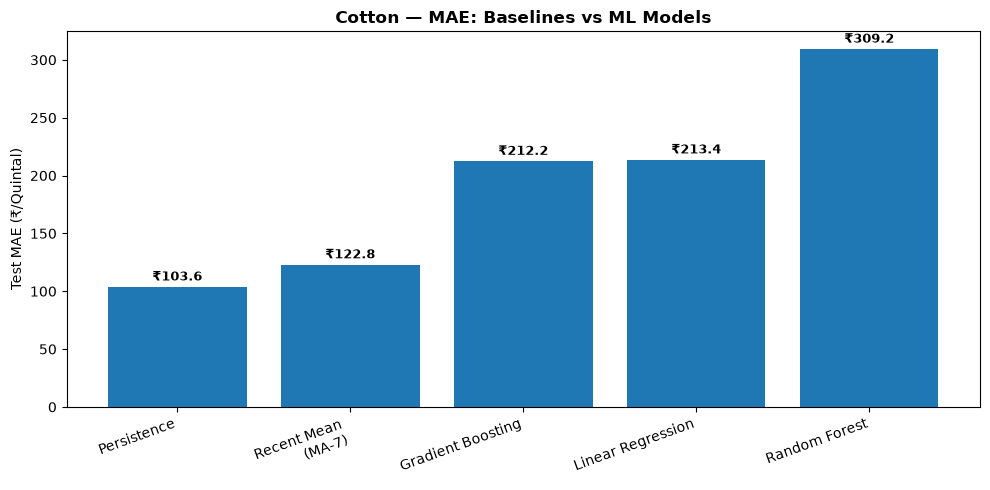

In [17]:
# MAE comparison bar charts
for crop in CROPS:
    rdf = all_results_dfs[crop]
    pers_mae = baselines_all[crop].get('Persistence', {}).get('MAE', 0)
    ma7_mae = baselines_all[crop].get('Recent Mean (MA-7)', {}).get('MAE', 0)

    methods = ['Persistence', 'Recent Mean\n(MA-7)'] + list(rdf['Model'])
    maes = [pers_mae, ma7_mae] + list(rdf['MAE'])

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(methods, maes)
    ax.set_ylabel('Test MAE (₹/Quintal)')
    ax.set_title(f'{crop} — MAE: Baselines vs ML Models', fontweight='bold')
    plt.xticks(rotation=20, ha='right')
    for bar, val in zip(bars, maes):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + max(maes)*0.01,
                f'₹{val:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    plt.tight_layout()
    plt.savefig(BASE_DIR / 'outputs' / f'{crop.lower()}_mae_comparison.png', dpi=120, bbox_inches='tight')
    plt.show()

---
### 17. Save Combined Model Comparison CSV

In [18]:
combined_rows = []
for crop, rdf in all_results_dfs.items():
    for _, row in rdf.iterrows():
        combined_rows.append({
            'crop': crop,
            'model': row['Model'],
            'MAE': row['MAE'],
            'RMSE': row['RMSE'],
            'MAPE': row['MAPE'],
            'R2': row['R2'],
            'persistence_MAE': row['Persistence_MAE'],
            'improvement_vs_persistence_MAE_pct': row['Improvement_vs_Persistence_MAE_pct'],
        })
combined_df = pd.DataFrame(combined_rows)
combined_df.to_csv(BASE_DIR / 'outputs' / 'multi_crop_model_comparison.csv', index=False)
print('Saved: outputs/multi_crop_model_comparison.csv')
display(combined_df)

Saved: outputs/multi_crop_model_comparison.csv


,crop,model,MAE,RMSE,MAPE,R2,persistence_MAE,improvement_vs_persistence_MAE_pct
0,Tomato,Random Forest,434.3620,549.8029,19.0385,0.6692,409.5864,-6.0489
1,Tomato,Linear Regression,452.4402,578.7675,20.0248,0.6334,409.5864,-10.4627
2,Tomato,Gradient Boosting,501.7680,625.8425,22.5035,0.5714,409.5864,-22.5060
3,Wheat,Gradient Boosting,68.2390,107.6109,2.2389,0.9505,66.9079,-1.9895
4,Wheat,Random Forest,68.3963,106.7716,2.2336,0.9513,66.9079,-2.2246
5,Wheat,Linear Regression,72.4299,109.5456,2.3657,0.9487,66.9079,-8.2531
6,Cotton,Gradient Boosting,212.2251,293.4315,2.5700,-0.9184,103.6250,-104.8011
7,Cotton,Linear Regression,213.4246,292.9814,2.5905,-0.9126,103.6250,-105.9586
8,Cotton,Random Forest,309.1840,414.4153,3.7497,-2.8265,103.6250,-198.3682


---
### 18. Final Summary Block (Part Q)

In [19]:
print('='*60)
print('MANDIMITRA STEP 7 — TOMATO / WHEAT / COTTON')
print('='*60)

for crop in CROPS:
    rdf = all_results_dfs[crop]
    best_name = rdf.iloc[0]['Model']
    bm = rdf.iloc[0]
    pers_mae = baselines_all[crop].get('Persistence', {}).get('MAE', float('nan'))
    beats = 'YES' if bm['MAE'] < pers_mae else 'NO'
    mkt_df = residuals_all[crop]['market']
    best_mkt = mkt_df.iloc[0]['Market'] if not mkt_df.empty else 'N/A'
    worst_mkt = mkt_df.iloc[-1]['Market'] if len(mkt_df) > 1 else mkt_df.iloc[0]['Market'] if not mkt_df.empty else 'N/A'
    best_mkt_mae = mkt_df.iloc[0]['MAE'] if not mkt_df.empty else float('nan')
    worst_mkt_mae = mkt_df.iloc[-1]['MAE'] if len(mkt_df) > 1 else float('nan')

    print(f'\n{crop.upper()}')
    print('-' * len(crop))
    print(f'Best ML Model:           {best_name}')
    print(f'ML MAE:                  ₹{bm["MAE"]:.2f}')
    print(f'ML RMSE:                 ₹{bm["RMSE"]:.2f}')
    print(f'ML MAPE:                 {bm["MAPE"]:.2f}%')
    print(f'ML R²:                   {bm["R2"]:.4f}')
    print(f'Persistence MAE:         ₹{pers_mae:.2f}')
    print(f'Improvement vs Pers:     {bm["Improvement_vs_Persistence_MAE_pct"]:.2f}%')
    print(f'ML beats Persistence:    {beats}')
    print(f'Best Market:             {best_mkt} (MAE: ₹{best_mkt_mae:.2f})')
    print(f'Worst Market:            {worst_mkt} (MAE: ₹{worst_mkt_mae:.2f})')

print('\nIMPORTANT COTTON LIMITATION:')
print('No group reached 500 observations.')
print('Adaptive >=300 threshold was used.')
print('Retained group: APMC Hinganghat | Other | FAQ')
print('Observations: 412')

print('\n' + '='*60)
print('OVERALL ML RESULT')
print('='*60)

header = f'{"Crop":<8} {"Best ML Model":<22} {"ML MAE":>10} {"Pers MAE":>10} {"ML Better?":>12} {"MAPE":>8}'
print(header)
print('-' * len(header))
for crop in CROPS:
    rdf = all_results_dfs[crop]
    best_name = rdf.iloc[0]['Model']
    bm = rdf.iloc[0]
    pers_mae = baselines_all[crop].get('Persistence', {}).get('MAE', float('nan'))
    beats = 'YES' if bm['MAE'] < pers_mae else 'NO'
    print(f'{crop:<8} {best_name:<22} {bm["MAE"]:>10.2f} {pers_mae:>10.2f} {beats:>12} {bm["MAPE"]:>7.2f}%')

# Analysis
maes_ml = {c: all_results_dfs[c].iloc[0]['MAE'] for c in CROPS}
pers_maes = {c: baselines_all[c].get('Persistence', {}).get('MAE', float('inf')) for c in CROPS}
improvements = {c: ((pers_maes[c] - maes_ml[c]) / pers_maes[c]) * 100 for c in CROPS}
train_sizes = {c: crop_data[c]['stats']['train_rows_after'] for c in CROPS}
mapes = {c: all_results_dfs[c].iloc[0]['MAPE'] for c in CROPS}

strongest_improvement = max(improvements, key=improvements.get)
weakest_performance = max(mapes, key=mapes.get)
best_coverage = max(train_sizes, key=train_sizes.get)
hardest_forecast = max(mapes, key=mapes.get)

print(f'\nStrongest ML improvement over persistence: {strongest_improvement} ({improvements[strongest_improvement]:.2f}%)')
print(f'Weakest ML performance (highest MAPE)    : {weakest_performance} ({mapes[weakest_performance]:.2f}%)')
print(f'Strongest data coverage (train rows)     : {best_coverage} ({train_sizes[best_coverage]:,} rows)')
print(f'Greatest forecasting difficulty (MAPE)   : {hardest_forecast} ({mapes[hardest_forecast]:.2f}%)')

print('\n' + '='*60)
print('RICE PROTECTION CHECK')
print('='*60)
rice_raw_ok = all((BASE_DIR/'data'/'processed'/f).exists() for f in ['maharashtra_2024_2026_combined.csv'])
rice_proc_ok = all((BASE_DIR/'data'/'processed'/f).exists() for f in [
    'maharashtra_rice_modeling_clean.csv','maharashtra_rice_features.csv',
    'maharashtra_rice_train.csv','maharashtra_rice_test.csv'])
rice_model_ok = (BASE_DIR/'models'/'mandimitra_rice_price_model.joblib').exists()
rice_outputs_ok = all((BASE_DIR/'outputs'/f).exists() for f in [
    'target_comparison.csv','model_comparison.csv','feature_importance.csv'])
print(f'Rice raw data untouched      : {"PASSED" if rice_raw_ok else "FAILED"}')
print(f'Rice processed data untouched: {"PASSED" if rice_proc_ok else "FAILED"}')
print(f'Rice model untouched         : {"PASSED" if rice_model_ok else "FAILED"}')
print(f'Rice outputs untouched       : {"PASSED" if rice_outputs_ok else "FAILED"}')
print('='*60)
print('STOP — Step 7 complete. Recommendation logic NOT started.')
print('='*60)

MANDIMITRA STEP 7 — TOMATO / WHEAT / COTTON

TOMATO
------
Best ML Model:           Random Forest
ML MAE:                  ₹434.36
ML RMSE:                 ₹549.80
ML MAPE:                 19.04%
ML R²:                   0.6692
Persistence MAE:         ₹409.59
Improvement vs Pers:     -6.05%
ML beats Persistence:    NO
Best Market:             Pune(Pimpri) (MAE: ₹321.37)
Worst Market:            Pune(Manjri) (MAE: ₹521.15)

WHEAT
-----
Best ML Model:           Gradient Boosting
ML MAE:                  ₹68.24
ML RMSE:                 ₹107.61
ML MAPE:                 2.24%
ML R²:                   0.9505
Persistence MAE:         ₹66.91
Improvement vs Pers:     -1.99%
ML beats Persistence:    NO
Best Market:             APMC Sillod (MAE: ₹30.05)
Worst Market:            APMC Ulhasnagar (MAE: ₹116.47)

COTTON
------
Best ML Model:           Gradient Boosting
ML MAE:                  ₹212.23
ML RMSE:                 ₹293.43
ML MAPE:                 2.57%
ML R²:                   -0.9184
Pe